# CSCV v5 — Overfitting Test for ORB + ITSM Strategy

Combinatorially Symmetric Cross-Validation (CSCV) / Probability of Backtest Overfitting (PBO).

**Setup:**
- All variants use `use_itsm_filter=True` (ITSM confluence locked on)
- Parameter grid: SL/TP x OR_BARS x EMA_PERIOD (same dimensions as v4)
- S = 16 splits → C(16,8) = 12,870 IS/OOS combinations
- Baseline: SL=70/TP=140/OR=8/EMA=10 (v5 candidate)

**Reference:** Bailey et al. (2015) — The Probability of Backtest Overfitting

In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

THIS_DIR     = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.abspath(os.path.join(THIS_DIR, '..', '..'))
NOTEBOOK_DIR = os.path.join(PROJECT_ROOT, 'notebooks', 'ORB_ITSM')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

from data_fetch import fetch_data
from cscv_itsm import build_pnl_matrix, run_cscv, sharpe_cols, pbo_verdict

print('Setup complete.')

Setup complete.


## Load Data

In [3]:
df = fetch_data(refresh=False)
print(f'Bars loaded : {len(df):,}')
print(f'Date range  : {df.index[0].date()} to {df.index[-1].date()}')

[data_fetch] Loading cached data from C:\Users\kunpa\Downloads\Projects\Futures_v2\data\NQ_5m.csv ...


[data_fetch] Loaded 222,295 rows (2014-12-19 -> 2026-03-17)
Bars loaded : 222,295
Date range  : 2014-12-19 to 2026-03-17


## Build Parameter Grid

Same grid as v4 — all variants have `use_itsm_filter=True`.

In [4]:
SL_TP_PAIRS  = [(40, 80), (50, 100), (60, 120), (70, 140), (80, 160)]
OR_BARS_LIST = [4, 6, 8]
EMA_PERIODS  = [10, 15, 20, 25]

variants = [
    {
        'sl_points':       sl,
        'tp_points':       tp,
        'or_bars':         orb,
        'ema_period':      ema,
        'use_itsm_filter': True,
    }
    for (sl, tp) in SL_TP_PAIRS
    for orb in OR_BARS_LIST
    for ema in EMA_PERIODS
]

N = len(variants)
print(f'N = {N} strategy variants (all with ITSM filter ON)')
print('Sample variants:')
for v in variants[:3]:
    print(f'  SL={v["sl_points"]} TP={v["tp_points"]} OR={v["or_bars"]}bars EMA={v["ema_period"]}')

N = 60 strategy variants (all with ITSM filter ON)
Sample variants:
  SL=40 TP=80 OR=4bars EMA=10
  SL=40 TP=80 OR=4bars EMA=15
  SL=40 TP=80 OR=4bars EMA=20


## Build P&L Matrix

In [5]:
print('Building P&L matrix...')
M, dates = build_pnl_matrix(df, variants)
T = M.shape[0]
print(f'P&L matrix shape: {M.shape}  (T={T} trading days, N={N} strategies)')
print(f'Date range: {dates[0].date()} to {dates[-1].date()}')

Building P&L matrix...


  10/60 variants complete...


  20/60 variants complete...


  30/60 variants complete...


  40/60 variants complete...


  50/60 variants complete...


  60/60 variants complete...


P&L matrix shape: (2246, 60)  (T=2246 trading days, N=60 strategies)
Date range: 2014-12-19 to 2026-03-16


## Run CSCV

In [6]:
S = 16
print(f'Running CSCV with S={S} splits ({S*(S-1)//2} combinations)...')
results = run_cscv(M, S=S)

pbo               = results['pbo']
logits            = results['logits']
is_sharpes        = results['is_sharpes']
oos_sharpes       = results['oos_sharpes']
selected_variants = results['selected_variants']
prob_loss         = float(np.mean(oos_sharpes < 0))

print(f'\nPBO  = {pbo*100:.1f}%  {pbo_verdict(pbo)}')
print(f'Median IS Sharpe  : {np.median(is_sharpes):.3f}')
print(f'Median OOS Sharpe : {np.median(oos_sharpes):.3f}')
print(f'Prob(loss OOS)    : {prob_loss*100:.1f}%')

Running CSCV with S=16 splits (120 combinations)...



PBO  = 65.9%  HIGH OVERFITTING RISK (PBO >= 50%)
Median IS Sharpe  : 1.263
Median OOS Sharpe : 0.820
Prob(loss OOS)    : 0.1%


## Chart 1 — Logit Distribution (PBO)

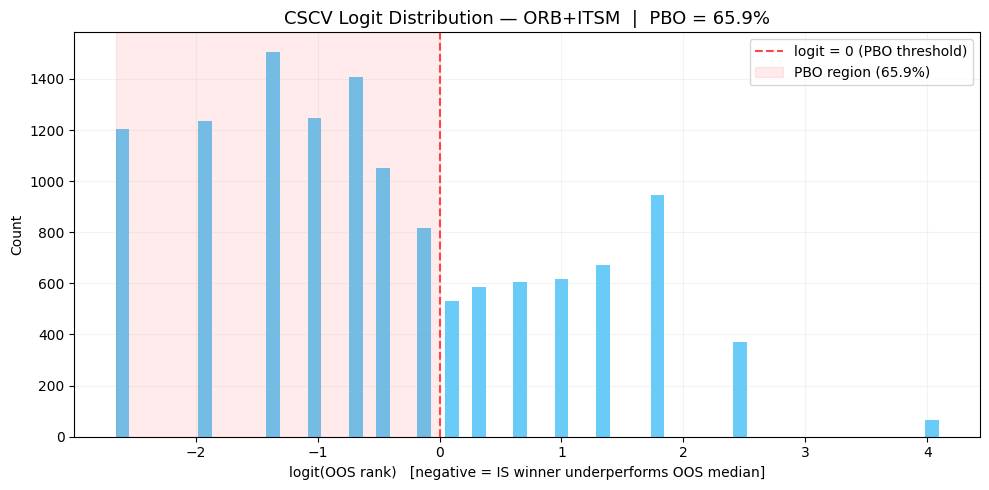

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(logits, bins=60, color='#4fc3f7', edgecolor='none', alpha=0.85)
ax.axvline(0, color='#ff4444', linewidth=1.5, linestyle='--', label='logit = 0 (PBO threshold)')
neg_frac = np.mean(logits < 0)
ax.axvspan(logits.min(), 0, alpha=0.08, color='red', label=f'PBO region ({neg_frac*100:.1f}%)')
ax.set_title(f'CSCV Logit Distribution — ORB+ITSM  |  PBO = {pbo*100:.1f}%', fontsize=13)
ax.set_xlabel('logit(OOS rank)   [negative = IS winner underperforms OOS median]')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()

## Chart 2 — IS vs OOS Sharpe Scatter

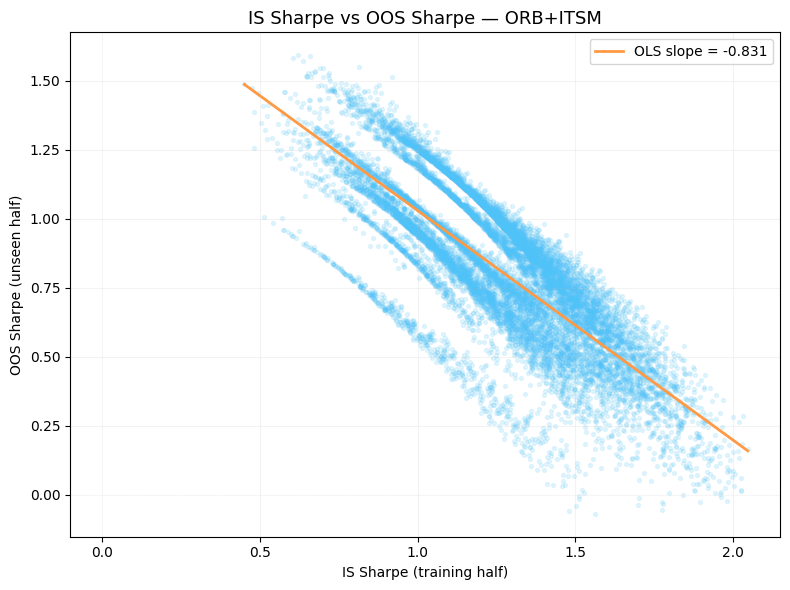

In [8]:
slope, intercept = np.polyfit(is_sharpes, oos_sharpes, 1)
x_line = np.linspace(is_sharpes.min(), is_sharpes.max(), 100)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(is_sharpes, oos_sharpes, alpha=0.15, s=8, color='#4fc3f7')
ax.plot(x_line, slope * x_line + intercept, color='#ff9944',
        linewidth=2, label=f'OLS slope = {slope:.3f}')
ax.axhline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
ax.axvline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
ax.set_title('IS Sharpe vs OOS Sharpe — ORB+ITSM', fontsize=13)
ax.set_xlabel('IS Sharpe (training half)')
ax.set_ylabel('OOS Sharpe (unseen half)')
ax.legend()
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()

## Chart 3 — OOS Sharpe Stochastic Dominance

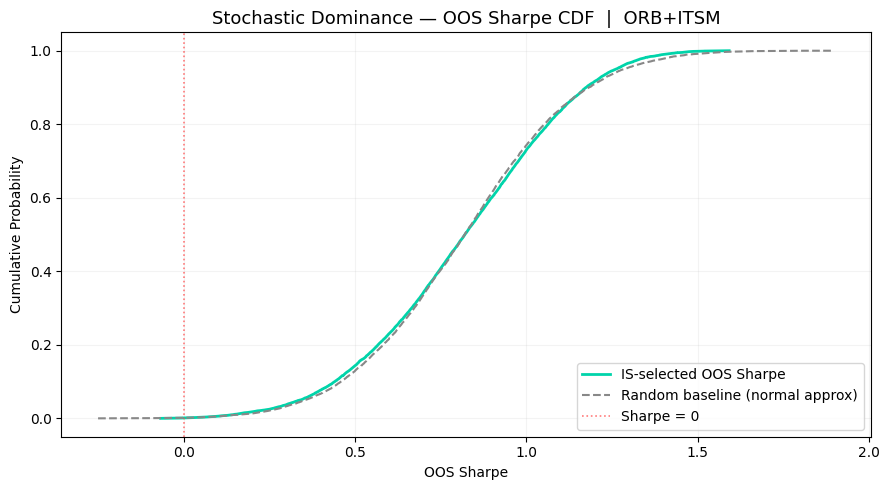

In [9]:
# Compare OOS Sharpe of IS-selected winner vs a random strategy
random_oos = M[np.random.choice(M.shape[0], size=M.shape[0], replace=False)].mean(axis=0)
random_sharpes = np.random.choice(oos_sharpes, size=len(oos_sharpes), replace=False)

sorted_oos    = np.sort(oos_sharpes)
sorted_random = np.sort(np.random.normal(np.median(oos_sharpes), np.std(oos_sharpes), len(oos_sharpes)))
cdf_y = np.arange(1, len(sorted_oos) + 1) / len(sorted_oos)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sorted_oos,    cdf_y, color='#00d4aa', linewidth=2, label='IS-selected OOS Sharpe')
ax.plot(sorted_random, cdf_y, color='#888888', linewidth=1.5, linestyle='--', label='Random baseline (normal approx)')
ax.axvline(0, color='#ff4444', linewidth=1.2, linestyle=':', alpha=0.7, label='Sharpe = 0')
ax.set_title('Stochastic Dominance — OOS Sharpe CDF  |  ORB+ITSM', fontsize=13)
ax.set_xlabel('OOS Sharpe')
ax.set_ylabel('Cumulative Probability')
ax.legend()
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()

## Section 5 — Summary

In [10]:
from IPython.display import display, Markdown

full_sharpes = sharpe_cols(M)
best_idx     = int(np.argmax(full_sharpes))
best_v       = variants[best_idx]

# Locate v5 baseline (SL=70, TP=140, OR=8, EMA=10)
baseline_idx = next(
    i for i, v in enumerate(variants)
    if v['sl_points'] == 70 and v['tp_points'] == 140
    and v['or_bars'] == 8 and v['ema_period'] == 10
)
baseline_rank = int(np.sum(full_sharpes <= full_sharpes[baseline_idx]))

sharpe_degradation_pct = (1 - np.median(oos_sharpes) / np.median(is_sharpes)) * 100

display(Markdown('### CSCV Setup'))
display(pd.DataFrame([
    ('N strategy variants',   N,                           'parameter combinations tested'),
    ('S splits',              S,                           'equal time slices of the dataset'),
    ('IS/OOS combinations',   f'{results["n_combos"]:,}',  'C(16,8) unique train/test splits'),
    ('T trading days',        T,                           'total rows in P&L matrix'),
    ('ITSM filter',           'ON (all variants)',          'use_itsm_filter=True for every variant'),
], columns=['Metric', 'Value', 'Description']))

display(Markdown('### Overfitting Diagnostics'))
display(pd.DataFrame([
    ('PBO',                f'{pbo*100:.1f}%',                         pbo_verdict(pbo)),
    ('Median IS Sharpe',   f'{np.median(is_sharpes):.3f}',            'Sharpe on training half'),
    ('Median OOS Sharpe',  f'{np.median(oos_sharpes):.3f}',           'Sharpe on unseen half'),
    ('Sharpe degradation', f'{sharpe_degradation_pct:.0f}%',          'IS to OOS drop'),
    ('OLS slope',          f'{slope:.3f}',                            '1.0 = no degradation, 0.0 = noise'),
    ('Prob of loss (OOS)', f'{prob_loss*100:.1f}%',                   'fraction of splits with negative OOS Sharpe'),
], columns=['Metric', 'Value', 'Notes']))

display(Markdown('### Parameter Comparison'))
display(pd.DataFrame([
    ('Best variant (CSCV full)',
     f'SL={best_v["sl_points"]}  TP={best_v["tp_points"]}  OR={best_v["or_bars"]}bars  EMA={best_v["ema_period"]}',
     f'{full_sharpes[best_idx]:.3f}',
     f'{best_idx + 1} / {N}'),
    ('v5 baseline (SL=70/TP=140/OR=8/EMA=10)',
     'SL=70  TP=140  OR=8bars  EMA=10',
     f'{full_sharpes[baseline_idx]:.3f}',
     f'{baseline_rank} / {N}'),
], columns=['Variant', 'Parameters', 'Full-Dataset Sharpe', 'Rank']))

display(Markdown('### Verdict'))
display(pd.DataFrame([
    ('Edge exists?',            'YES' if prob_loss < 0.1 else 'UNCERTAIN',
     f'Prob(loss OOS) = {prob_loss*100:.1f}%'),
    ('Parameters overfit?',     pbo_verdict(pbo),
     f'PBO = {pbo*100:.1f}%'),
    ('Forward Sharpe estimate', f'~{np.median(oos_sharpes):.2f}',
     f'vs IS median {np.median(is_sharpes):.3f}'),
    ('Beats S&P 500 Sharpe?',  'YES' if np.median(oos_sharpes) > 0.6 else 'NO',
     f'OOS median {np.median(oos_sharpes):.3f} vs S&P 500 ~0.60'),
    ('vs ORB-only PBO (v4)',    '47.7% was ORB-only PBO',
     'compare to see if ITSM filter reduces overfitting'),
], columns=['Question', 'Answer', 'Detail']))

### CSCV Setup

,Metric,Value,Description
0,N strategy variants,60,parameter combinations tested
1,S splits,16,equal time slices of the dataset
2,IS/OOS combinations,"12,870","C(16,8) unique train/test splits"
3,T trading days,2246,total rows in P&L matrix
4,ITSM filter,ON (all variants),use_itsm_filter=True for every variant


### Overfitting Diagnostics

,Metric,Value,Notes
0,PBO,65.9%,HIGH OVERFITTING RISK (PBO >= 50%)
1,Median IS Sharpe,1.263,Sharpe on training half
2,Median OOS Sharpe,0.820,Sharpe on unseen half
3,Sharpe degradation,35%,IS to OOS drop
4,OLS slope,-0.831,"1.0 = no degradation, 0.0 = noise"
5,Prob of loss (OOS),0.1%,fraction of splits with negative OOS Sharpe


### Parameter Comparison

,Variant,Parameters,Full-Dataset Sharpe,Rank
0,Best variant (CSCV full),SL=60 TP=120 OR=4bars EMA=10,1.086,25 / 60
1,v5 baseline (SL=70/TP=140/OR=8/EMA=10),SL=70 TP=140 OR=8bars EMA=10,0.952,44 / 60


### Verdict

,Question,Answer,Detail
0,Edge exists?,YES,Prob(loss OOS) = 0.1%
1,Parameters overfit?,HIGH OVERFITTING RISK (PBO >= 50%),PBO = 65.9%
2,Forward Sharpe estimate,~0.82,vs IS median 1.263
3,Beats S&P 500 Sharpe?,YES,OOS median 0.820 vs S&P 500 ~0.60
4,vs ORB-only PBO (v4),47.7% was ORB-only PBO,compare to see if ITSM filter reduces overfitting
